# Semana 6: Árboles de Decisión y Random Forest
## Notebook Conceptual (NB1) – Construcción Manual y Visualización

**Propósito:** Entender cómo funcionan los árboles de decisión, su interpretabilidad y el ensamble bagging (Random Forest) para reducir varianza.

**Docente:** Carlos César Sánchez Coronel

**Objetivos de aprendizaje:**
- Implementar un árbol de decisión recursivo usando el índice de Gini.
- Visualizar las particiones del espacio y la estructura del árbol.
- Experimentar con hiperparámetros (max_depth, min_samples_split) y observar sobreajuste.
- Visualizar la importancia de características en datos con variables ruidosas.
- Construir un Random Forest y visualizar fronteras de árboles individuales vs el conjunto.
- Comparar el error OOB (Out-of-Bag) con validación cruzada.

---

## 0. Configuración Inicial

Importamos las librerías necesarias y fijamos la semilla para reproducibilidad.

In [1]:
# Importamos librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

# Scikit-learn
from sklearn.datasets import make_classification, make_moons, make_circles
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Configuración de visualización
%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# Semilla
np.random.seed(42)

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


---
## 1. Generación de Datos Sintéticos en 2D (3 clases)

Creamos un dataset con 2 características y 3 clases para visualizar fácilmente las particiones del árbol.

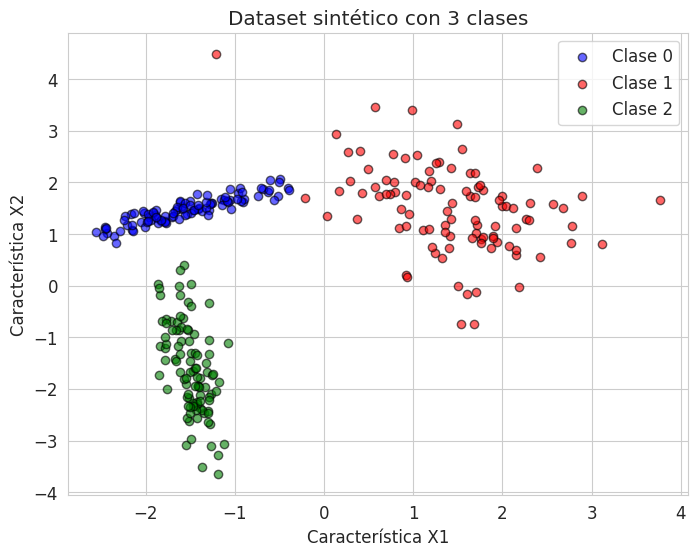

In [2]:
# Generamos datos con 3 clases
X, y = make_classification(
    n_samples=300,
    n_features=2,
    n_redundant=0,
    n_clusters_per_class=1,
    n_classes=3,
    class_sep=1.5,
    random_state=42
)

# Visualizamos
plt.figure(figsize=(8, 6))
colors = ['blue', 'red', 'green']
for class_idx in range(3):
    plt.scatter(X[y==class_idx, 0], X[y==class_idx, 1],
                c=colors[class_idx], label=f'Clase {class_idx}', alpha=0.6, edgecolors='k')
plt.xlabel('Característica X1')
plt.ylabel('Característica X2')
plt.title('Dataset sintético con 3 clases')
plt.legend()
plt.grid(True)
plt.show()

---
## 2. Implementación Manual de un Árbol de Decisión

Implementamos un árbol de decisión simple usando el índice de Gini.

**Índice de Gini:**
$$G = 1 - \sum_{k=1}^{K} p_k^2$$

**Ganancia:** Disminución del Gini ponderado al hacer una división.

In [3]:
def gini(y):
    """Calcula el índice de Gini para un conjunto de etiquetas"""
    if len(y) == 0:
        return 0
    classes = np.unique(y)
    probs = [np.sum(y == c) / len(y) for c in classes]
    return 1 - np.sum(np.array(probs)**2)

def mejor_division(X, y):
    """Encuentra la mejor característica y umbral para dividir"""
    mejor_gini = float('inf')
    mejor_caract = None
    mejor_umbral = None

    n_muestras, n_caracts = X.shape

    # Si todas las etiquetas son iguales, no hay necesidad de dividir
    if len(np.unique(y)) == 1:
        return None, None

    for caracteristica in range(n_caracts):
        valores = X[:, caracteristica]
        umbrales = np.unique(valores)

        for umbral in umbrales:
            # Dividir según el umbral
            izquierda = y[valores <= umbral]
            derecha = y[valores > umbral]

            if len(izquierda) == 0 or len(derecha) == 0:
                continue

            # Gini ponderado
            gini_izq = gini(izquierda)
            gini_der = gini(derecha)
            gini_ponderado = (len(izquierda) * gini_izq + len(derecha) * gini_der) / len(y)

            if gini_ponderado < mejor_gini:
                mejor_gini = gini_ponderado
                mejor_caract = caracteristica
                mejor_umbral = umbral

    return mejor_caract, mejor_umbral

class ArbolManual:
    def __init__(self, max_depth=3):
        self.max_depth = max_depth
        self.arbol = None

    def fit(self, X, y, depth=0):
        """Construye el árbol recursivamente"""
        # Si profundidad máxima alcanzada o todas las etiquetas iguales
        if depth >= self.max_depth or len(np.unique(y)) == 1:
            return {'clase': np.bincount(y).argmax(), 'n_muestras': len(y), 'gini': gini(y)}

        # Encontrar mejor división
        caracteristica, umbral = mejor_division(X, y)

        if caracteristica is None:
            return {'clase': np.bincount(y).argmax(), 'n_muestras': len(y), 'gini': gini(y)}

        # Dividir datos
        izquierda_idx = X[:, caracteristica] <= umbral
        derecha_idx = X[:, caracteristica] > umbral

        # Construir subárboles
        izquierda = self.fit(X[izquierda_idx], y[izquierda_idx], depth+1)
        derecha = self.fit(X[derecha_idx], y[derecha_idx], depth+1)

        return {
            'caracteristica': caracteristica,
            'umbral': umbral,
            'izquierda': izquierda,
            'derecha': derecha,
            'n_muestras': len(y),
            'gini': gini(y)
        }

    def predict_one(self, x, nodo):
        """Predice para una muestra"""
        if 'clase' in nodo:
            return nodo['clase']
        if x[nodo['caracteristica']] <= nodo['umbral']:
            return self.predict_one(x, nodo['izquierda'])
        else:
            return self.predict_one(x, nodo['derecha'])

    def predict(self, X):
        return np.array([self.predict_one(x, self.arbol) for x in X])

# Entrenamos el árbol manual
arbol_manual = ArbolManual(max_depth=3)
arbol_manual.arbol = arbol_manual.fit(X, y)

# Predicciones
y_pred_manual = arbol_manual.predict(X)
print(f"Precisión del árbol manual (profundidad 3): {accuracy_score(y, y_pred_manual):.4f}")

Precisión del árbol manual (profundidad 3): 1.0000


## 3. Visualización de las Particiones del Espacio

Visualizamos cómo el árbol divide el espacio de características.

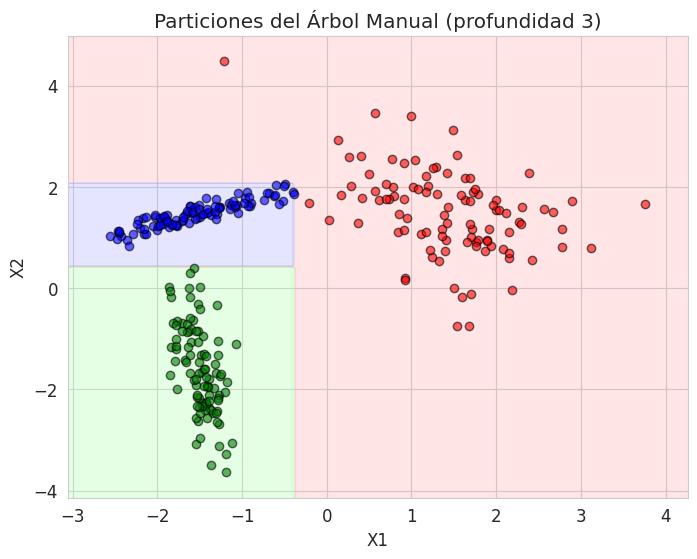

In [4]:
def plot_decision_boundary_arbol(model, X, y, ax, title, modelo_sklearn=False):
    # Crear malla
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))

    # Predecir sobre la malla
    if modelo_sklearn:
        Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    else:
        Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Dibujar contorno
    colors = ['blue', 'red', 'green']
    cmap = ListedColormap(['#AAAAFF', '#FFAAAA', '#AAFFAA'])
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=cmap)

    # Dibujar puntos
    for class_idx in range(3):
        ax.scatter(X[y==class_idx, 0], X[y==class_idx, 1],
                   c=colors[class_idx], label=f'Clase {class_idx}', alpha=0.6, edgecolors='k')
    ax.set_title(title)
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
plot_decision_boundary_arbol(arbol_manual, X, y, ax, 'Particiones del Árbol Manual (profundidad 3)')
plt.show()

---
## 4. Árbol de Decisión con scikit-learn y Efecto de Hiperparámetros

Usamos DecisionTreeClassifier y observamos cómo cambia la frontera al variar `max_depth` y `min_samples_split`.

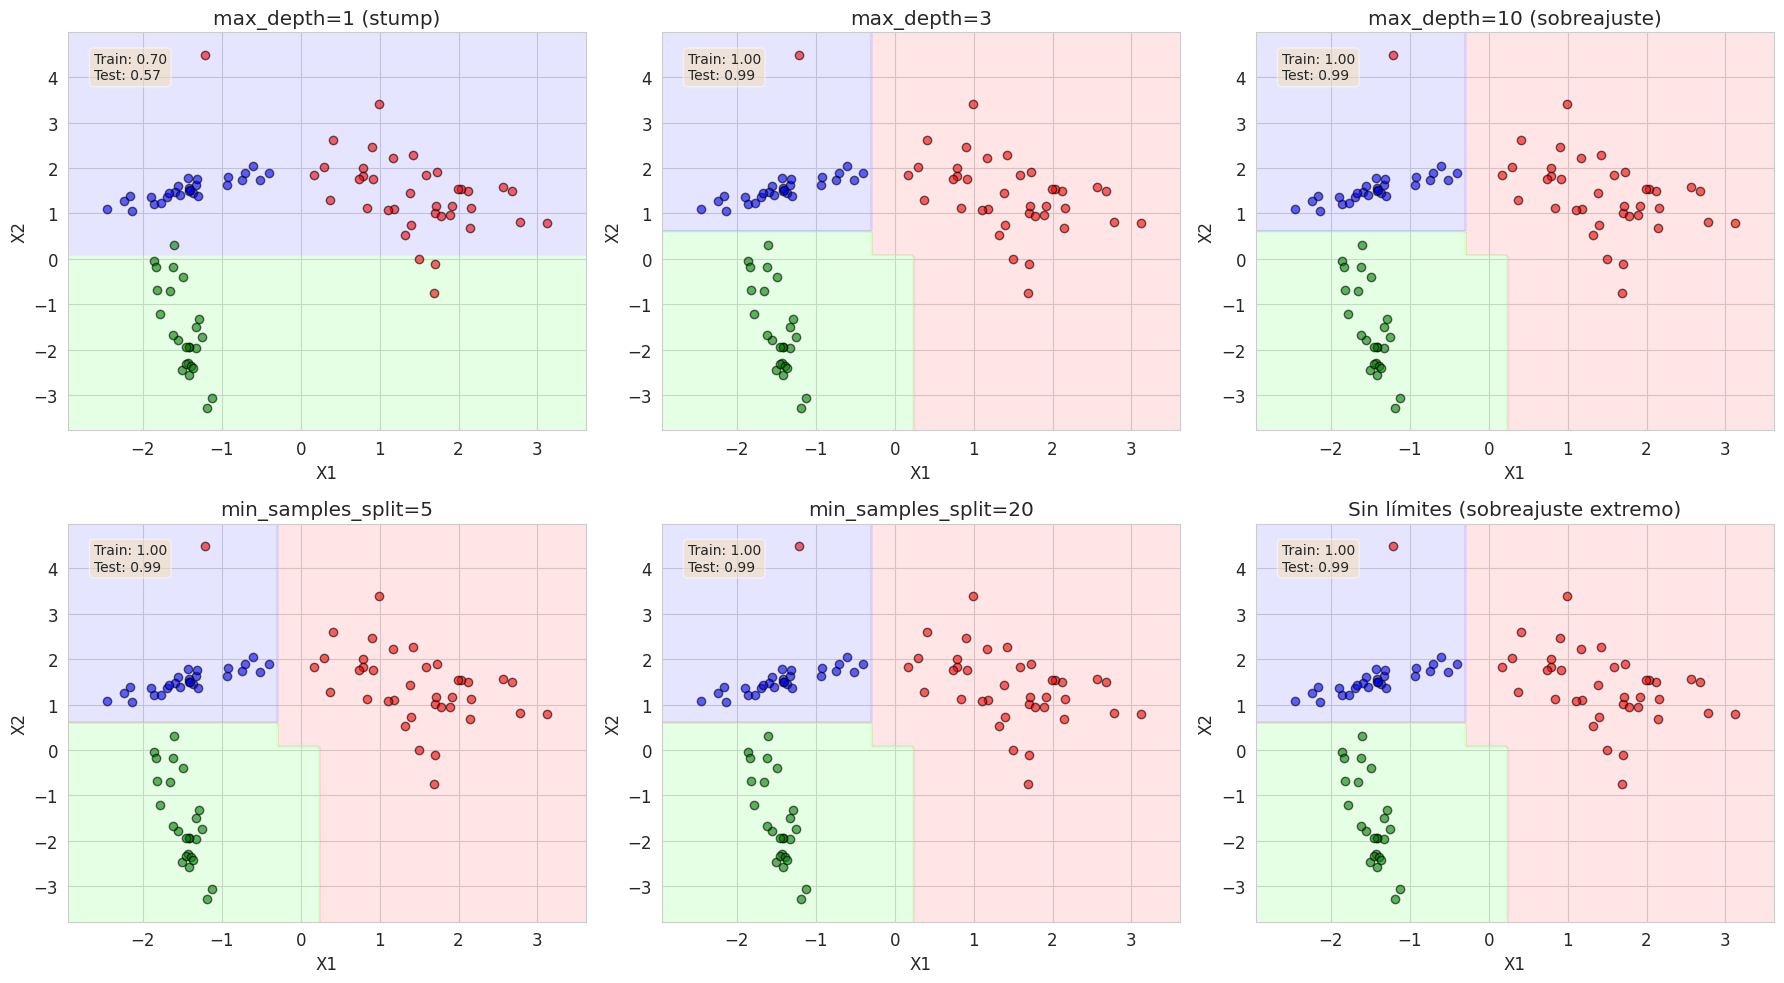

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

# Diferentes configuraciones
configs = [
    {'max_depth': 1, 'min_samples_split': 2, 'title': 'max_depth=1 (stump)'},
    {'max_depth': 3, 'min_samples_split': 2, 'title': 'max_depth=3'},
    {'max_depth': 10, 'min_samples_split': 2, 'title': 'max_depth=10 (sobreajuste)'},
    {'max_depth': 3, 'min_samples_split': 5, 'title': 'min_samples_split=5'},
    {'max_depth': 3, 'min_samples_split': 20, 'title': 'min_samples_split=20'},
    {'max_depth': None, 'min_samples_split': 2, 'title': 'Sin límites (sobreajuste extremo)'}
]

for i, config in enumerate(configs):
    # Extract title and create a new dictionary with only DecisionTreeClassifier arguments
    dt_params = {k: v for k, v in config.items() if k != 'title'}
    dt = DecisionTreeClassifier(**dt_params, random_state=42)
    dt.fit(X_train, y_train)
    plot_decision_boundary_arbol(dt, X_test, y_test, axes[i], config['title'], modelo_sklearn=True)
    train_acc = accuracy_score(y_train, dt.predict(X_train))
    test_acc = accuracy_score(y_test, dt.predict(X_test))
    axes[i].text(0.05, 0.95, f'Train: {train_acc:.2f}\nTest: {test_acc:.2f}',
                 transform=axes[i].transAxes, fontsize=10, verticalalignment='top',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

## 5. Visualización de la Estructura del Árbol

Usamos `plot_tree` para ver la estructura jerárquica del árbol.

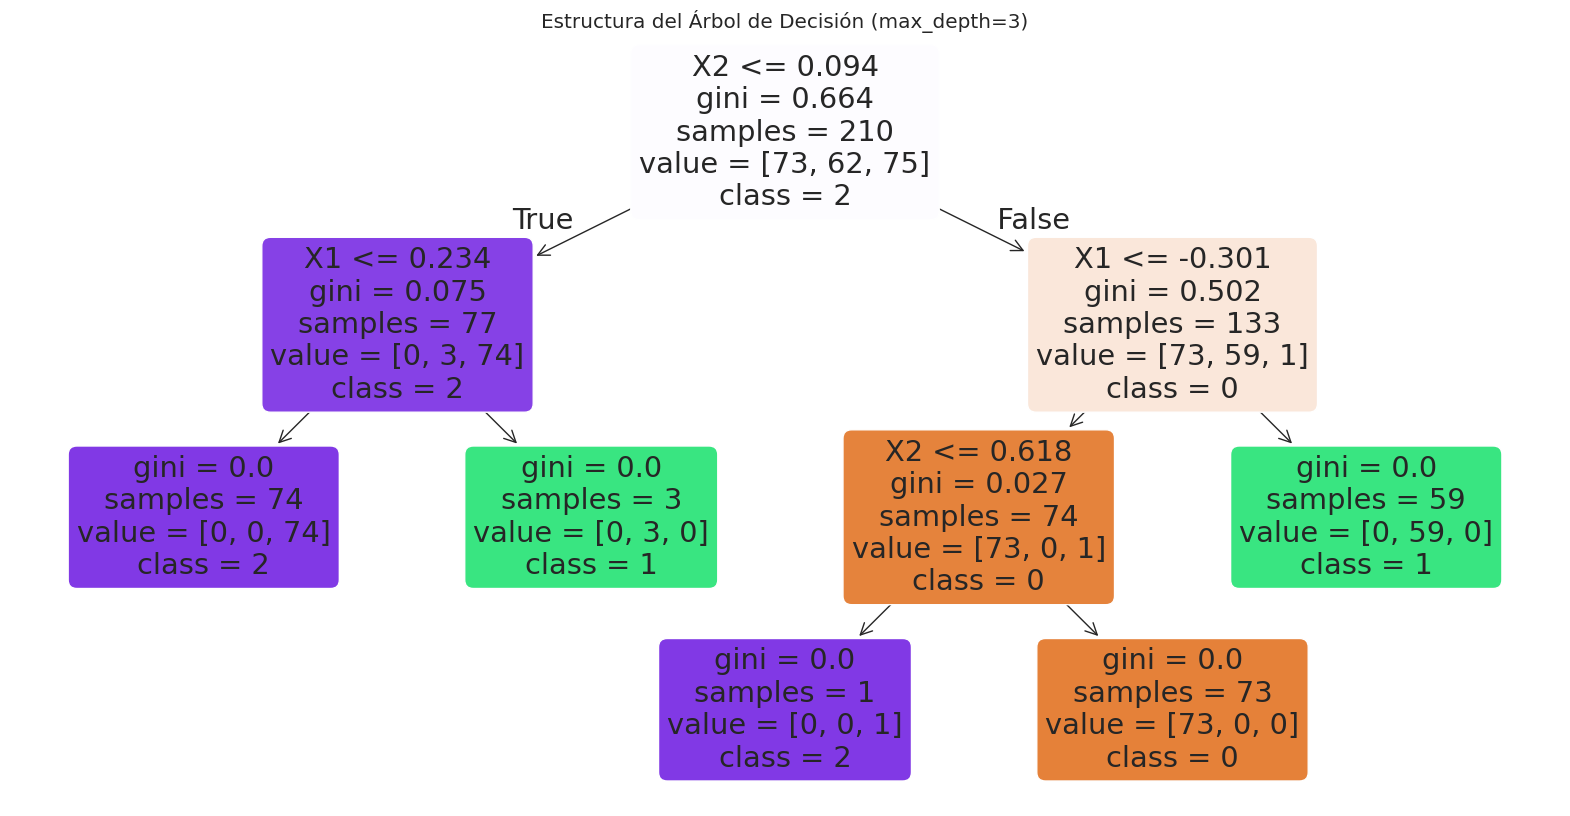

In [7]:
dt_viz = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_viz.fit(X_train, y_train)

plt.figure(figsize=(20, 10))
plot_tree(dt_viz, filled=True, feature_names=['X1', 'X2'], class_names=['0', '1', '2'], rounded=True)
plt.title('Estructura del Árbol de Decisión (max_depth=3)')
plt.show()

---
## 6. Importancia de Características (Gini Importance)

Creamos un dataset con variables ruidosas para ver cómo el árbol identifica las relevantes.

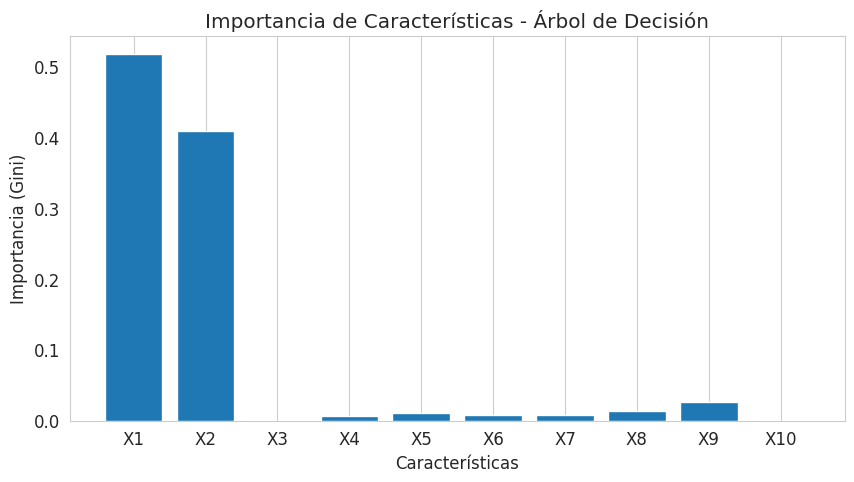

Las primeras dos características (X1, X2) deberían tener mayor importancia.


In [8]:
# Generamos datos con 10 características, pero solo 2 son informativas
np.random.seed(42)
n_samples = 500
n_features = 10

# Características informativas
X1 = np.random.randn(n_samples) * 2
X2 = np.random.randn(n_samples) * 2

# Ruido
ruido = np.random.randn(n_samples, n_features-2)

# Construimos X
X_imp = np.column_stack([X1, X2, ruido])

# y depende solo de X1 y X2
y_imp = (X1 + X2 + np.random.randn(n_samples) * 0.5) > 0
y_imp = y_imp.astype(int)

# Entrenamos un árbol
dt_imp = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_imp.fit(X_imp, y_imp)

# Visualizamos importancia
importances = dt_imp.feature_importances_
feature_names = [f'X{i+1}' for i in range(n_features)]

plt.figure(figsize=(10, 5))
plt.bar(feature_names, importances)
plt.xlabel('Características')
plt.ylabel('Importancia (Gini)')
plt.title('Importancia de Características - Árbol de Decisión')
plt.grid(axis='y')
plt.show()

print("Las primeras dos características (X1, X2) deberían tener mayor importancia.")

---
## 7. Random Forest: Visualización de Árboles Individuales vs Combinado

Construimos un Random Forest con pocos árboles y visualizamos sus fronteras individuales y la combinada.

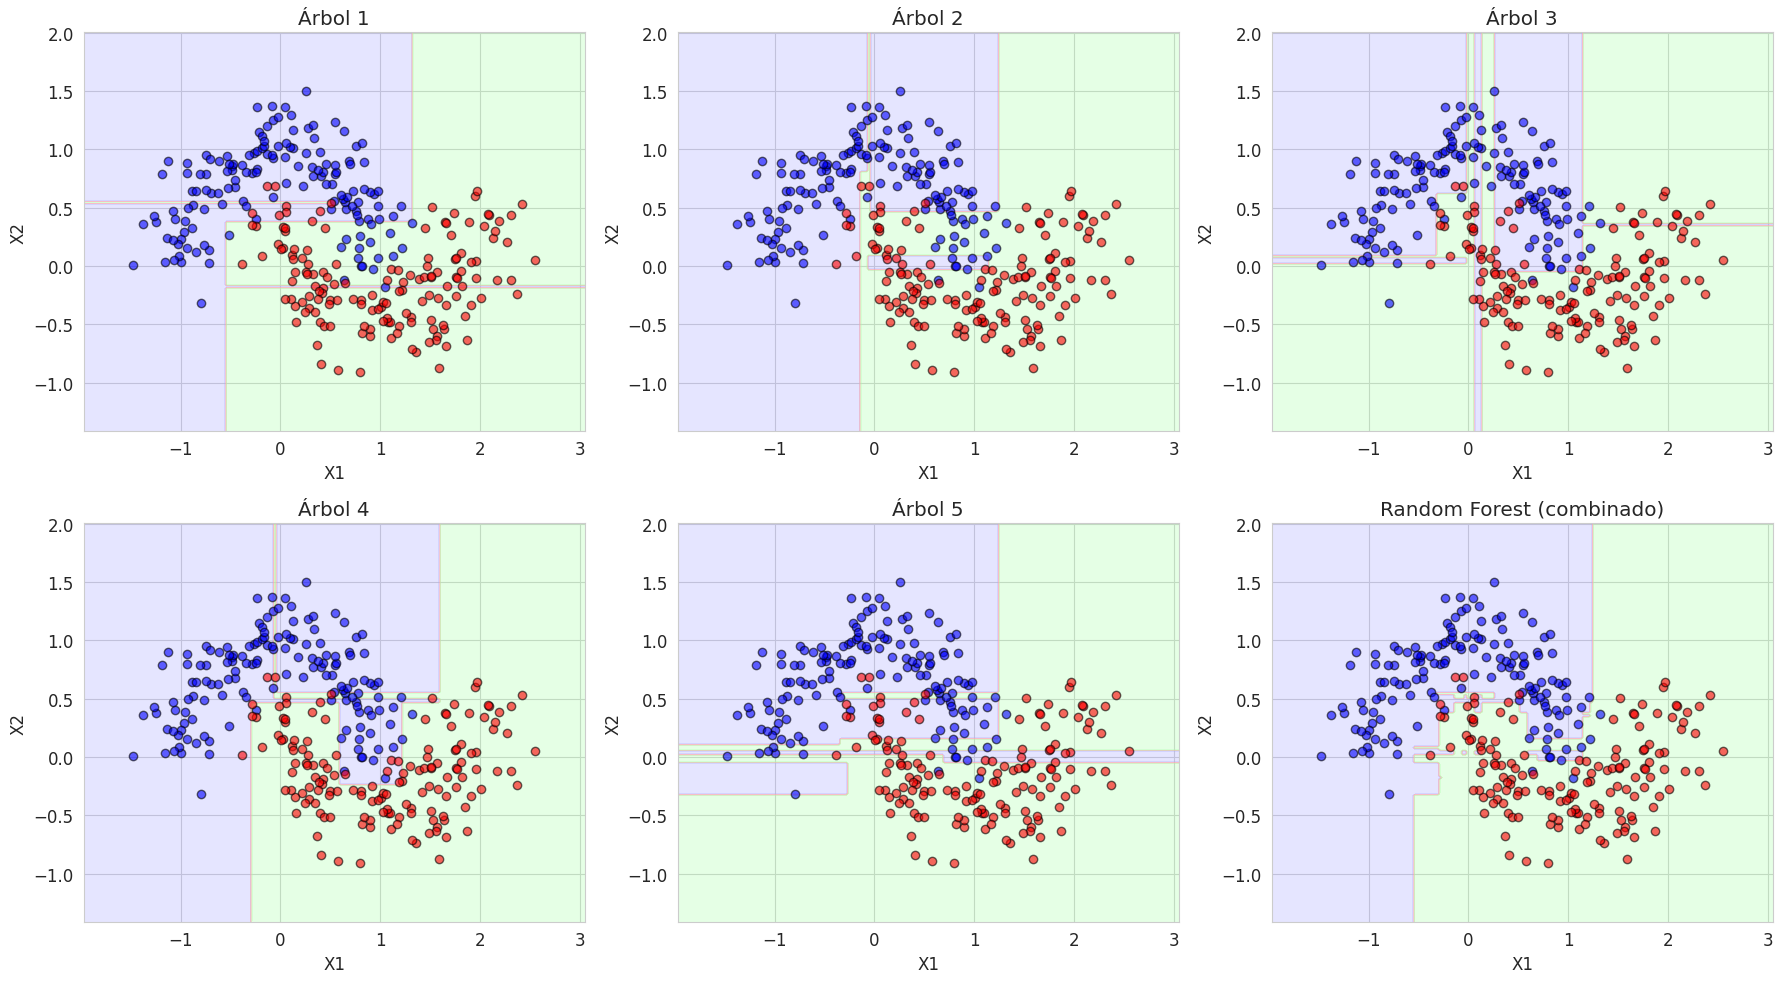

In [9]:
# Usamos datos de lunas para un problema no lineal
X_rf, y_rf = make_moons(n_samples=300, noise=0.2, random_state=42)

# Random Forest con 5 árboles
rf = RandomForestClassifier(n_estimators=5, max_depth=5, random_state=42)
rf.fit(X_rf, y_rf)

# Visualizamos cada árbol individual y el conjunto
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

# Árboles individuales
for i, arbol in enumerate(rf.estimators_):
    plot_decision_boundary_arbol(arbol, X_rf, y_rf, axes[i], f'Árbol {i+1}', modelo_sklearn=True)

# Random Forest combinado
plot_decision_boundary_arbol(rf, X_rf, y_rf, axes[5], 'Random Forest (combinado)', modelo_sklearn=True)

plt.tight_layout()
plt.show()

---
## 8. Error Out-of-Bag (OOB) vs Validación Cruzada

Random Forest puede estimar el error de prueba sin necesidad de validación cruzada usando las muestras OOB.

Error OOB (accuracy): 0.9952
Validación cruzada (5-fold): 0.9952 (+/- 0.0190)
Accuracy en test: 0.9889


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too fe

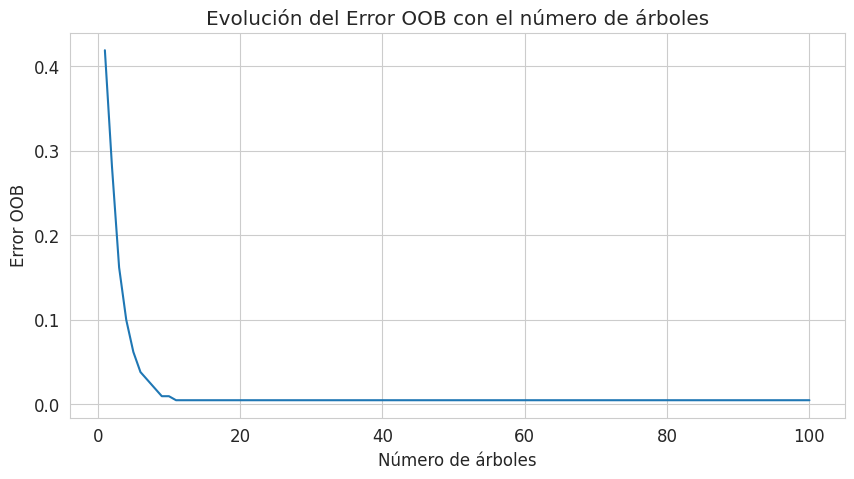

In [10]:
# Random Forest con OOB activado
rf_oob = RandomForestClassifier(n_estimators=100, oob_score=True, random_state=42)
rf_oob.fit(X_train, y_train)

print(f"Error OOB (accuracy): {rf_oob.oob_score_:.4f}")

# Validación cruzada estándar
cv_scores = cross_val_score(RandomForestClassifier(n_estimators=100, random_state=42),
                            X_train, y_train, cv=5, scoring='accuracy')
print(f"Validación cruzada (5-fold): {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")

# Evaluación en test
test_acc = accuracy_score(y_test, rf_oob.predict(X_test))
print(f"Accuracy en test: {test_acc:.4f}")

# Evolución del error OOB con el número de árboles
oob_errors = []
for n in range(1, 101):
    rf_temp = RandomForestClassifier(n_estimators=n, oob_score=True, random_state=42, warm_start=True)
    rf_temp.fit(X_train, y_train)
    oob_errors.append(1 - rf_temp.oob_score_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 101), oob_errors)
plt.xlabel('Número de árboles')
plt.ylabel('Error OOB')
plt.title('Evolución del Error OOB con el número de árboles')
plt.grid(True)
plt.show()

---
## 9. Experimentación Adicional: Árbol vs Random Forest

Comparamos un árbol único con Random Forest en términos de sobreajuste.

=== Comparación Árbol vs Random Forest ===
Árbol profundo - Train acc: 1.0000
Árbol profundo - Test acc: 0.9889
Random Forest - Train acc: 1.0000
Random Forest - Test acc: 0.9889


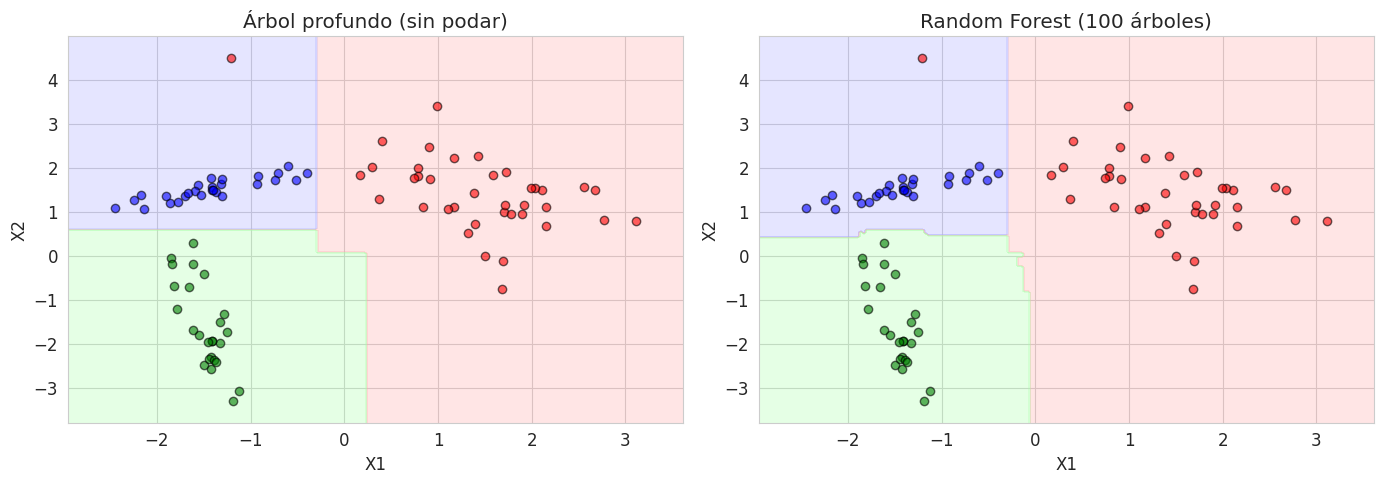

In [11]:
# Árbol profundo (sin podar)
dt_deep = DecisionTreeClassifier(max_depth=None, random_state=42)
dt_deep.fit(X_train, y_train)

# Random Forest
rf_comp = RandomForestClassifier(n_estimators=100, random_state=42)
rf_comp.fit(X_train, y_train)

print("=== Comparación Árbol vs Random Forest ===")
print(f"Árbol profundo - Train acc: {accuracy_score(y_train, dt_deep.predict(X_train)):.4f}")
print(f"Árbol profundo - Test acc: {accuracy_score(y_test, dt_deep.predict(X_test)):.4f}")
print(f"Random Forest - Train acc: {accuracy_score(y_train, rf_comp.predict(X_train)):.4f}")
print(f"Random Forest - Test acc: {accuracy_score(y_test, rf_comp.predict(X_test)):.4f}")

# Visualización de fronteras
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_decision_boundary_arbol(dt_deep, X_test, y_test, axes[0], 'Árbol profundo (sin podar)', modelo_sklearn=True)
plot_decision_boundary_arbol(rf_comp, X_test, y_test, axes[1], 'Random Forest (100 árboles)', modelo_sklearn=True)

plt.tight_layout()
plt.show()

---
## 10. Conclusiones

Hemos explorado los fundamentos de los árboles de decisión y Random Forest:

✔️ **Implementación manual**: Construimos un árbol recursivo usando el índice de Gini.
✔️ **Particiones del espacio**: Visualizamos cómo los árboles dividen el espacio.
✔️ **Efecto de hiperparámetros**: `max_depth` controla la complejidad; valores altos causan sobreajuste.
✔️ **Importancia de características**: El árbol identifica las variables más relevantes.
✔️ **Random Forest**: Combina múltiples árboles, suavizando la frontera y reduciendo varianza.
✔️ **Error OOB**: Proporciona una estimación interna del error, similar a validación cruzada.

**Lección clave**: Los árboles individuales son interpretables pero propensos a sobreajuste. Random Forest sacrifica interpretabilidad global por mayor precisión y estabilidad.

En el próximo notebook (NB2) aplicaremos estos conceptos a un problema real de riesgo crediticio.

---
**Fin del Notebook Conceptual - Semana 6**